# Example: Training Small Boltzmann Machines

In this example, we will explore how to train a small Boltzmann machine using exact gradient ascent. In particular, we'll look at how the composition of the training data determines the learned distribution, and what happens when training patterns are duplicated or naturally sampled.

> __Learning Objectives__
>
> By the end of this example, you should be able to:
> * __Train a Boltzmann machine:__ Use the gradient ascent training algorithm to train a Boltzmann machine on a small set of patterns, and verify that the learned distribution assigns higher probability to the training patterns.
> * __Understand distribution collapse:__ Explain why training on manually duplicated patterns causes the learned distribution to collapse to a single configuration, using the data correlation matrix to trace the mechanism.
> * __Fix distribution collapse:__ Apply L2 weight regularization and natural sampling to prevent weight divergence and recover an approximate target distribution.


Let's get started!
___

## Background: What is a Boltzmann Machine?
A [Boltzmann Machine](https://en.wikipedia.org/wiki/Boltzmann_machine) consists of a set of binary units (neurons, nodes, vertices, etc.) that are fully connected, with no self-connections. Formally, [a Boltzmann Machine](https://en.wikipedia.org/wiki/Boltzmann_machine) $\mathcal{B}$ is a fully connected _undirected weighted graph_ defined by the tuple $\mathcal{B} = \left(\mathcal{V},\mathcal{E}, \mathbf{W},\mathbf{b}, \mathbf{s}\right)$.
* __Units__: Each unit (vertex, node, neuron) $v_{i}\in\mathcal{V}$ has a binary state (`on` or `off`) and a bias value 
$b_{i}\in\mathbb{R}$, where $b_{i}$ is the bias of the node $v_{i}$. The bias vector $\mathbf{b}\in\mathbb{R}^{|\mathcal{V}|}$ is the vector of bias values for all nodes in the network. 
* __Edges__: Each edge $e\in\mathcal{E}$ has a weight. The weight of the edge connecting $v_{i}\in\mathcal{V}$ and $v_{j}\in\mathcal{V}$, is denoted by $w_{ij}\in\mathbf{W}$, where the weight matrix $\mathbf{W}\in\mathbb{R}^{|\mathcal{V}|\times|\mathcal{V}|}$ is symmetric, i.e. $w_{ij} = w_{ji}$ and $w_{ii} = 0$ (no self loops). The weights $w_{ij}\in\mathbb{R}$ determine the strength of the connection between the two nodes. 
* __States__: The state of each node is represented by a binary vector $\mathbf{s}\in\{-1,1\}^{|\mathcal{V}|}$, where $s_{i}\in\{-1,1\}$ is the state of node $v_{i}$. When $s_{i} = 1$, the node is `on`, and when $s_{i} = -1$, the node is `off`. The set of all possible state _configurations_ is denoted by $\mathcal{S} \equiv \left\{\mathbf{s}^{(1)},\mathbf{s}^{(2)},\ldots,\mathbf{s}^{(N)}\right\}$, where $N$ is the number of possible state configurations, or $N = 2^{|\mathcal{V}|}$ for binary units.

Suppose we have values for the weights $\mathbf{W}$ and biases $\mathbf{b}$ of the Boltzmann machine. One of the key questions we can ask is: how can we generate samples from this Boltzmann machine?

### Sampling algorithm
One of the key theoretical ideas of [the Boltzmann machine](https://en.wikipedia.org/wiki/Boltzmann_machine) is that the samples generated from it are distributed according to [the Boltzmann distribution](https://en.wikipedia.org/wiki/Boltzmann_distribution). Let's test this idea. 

To generate samples from a Boltzmann Machine, let us consider the following algorithm (Gibbs sampling): 

__Initialize__ the weights $\mathbf{W}$ and biases $\mathbf{b}$ of the Boltzmann Machine. Provide an initial state $\mathbf{s}^{(0)}$ of the network, and a system temperature $\beta$.

For each turn $t=1,2,\dots,T$:
1. For each node $v_{i}\in\mathcal{V}$:
    1. Compute the total input $h_{i}^{(t)}$ to node $v_{i}$ using $h_{i}^{(t)} = \sum_{j\in\mathcal{V}} w_{ij}s_{j}^{(t-1)} + b_{i}$.
    2. Compute the probability of the _next_ state $s_{i}^{(t)} = 1$ using the logistic function $P(s_{i}^{(t)} = 1 \mid s_{\lnot{i}}) = \left(1+\exp(-2\beta\cdot{h}_{i}^{(t)})\right)^{-1}$ for node $v_{i}$. The factor of $2$ arises because flipping $s_{i}$ between $\{-1,+1\}$ changes the energy by $2h_{i}^{(t)}$. The probability of $s_{i}^{(t)} = -1$ is given by $P(s_{i}^{(t)} = -1 \mid s_{\lnot{i}}) = 1 - P(s_{i}^{(t)} = 1 \mid s_{\lnot{i}})$.
    3. Sample the _next_ state of node $v_{i}$ from a [Bernoulli distribution](https://en.wikipedia.org/wiki/Bernoulli_distribution) with parameter $p = P(s_{i}^{(t)} = 1 \mid s_{\lnot{i}})$.
2. Store the state vector $\mathbf{s}^{(t)}$ of the network at turn $t$, and proceed to the next turn.


We've implemented this algorithm [in the `sample(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/boltzmann/#VLDataScienceMachineLearningPackage.sample-Tuple{MySimpleBoltzmannMachineModel,%20Vector{Int64}}). Let's use it to generate samples from a small Boltzmann machine and see how the empirical distribution of the samples compares to the theoretical Boltzmann distribution.
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.

> __Environment Setup with Include.jl__
>
> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Constants 
Set some constants that we will use later. Please look at the comments in the code for more details on each constant's permissible values, units, etc. 

In [2]:
number_of_nodes = 3; # number of nodes in the system
β = 100.0; # inverse temperature parameter for the system (big: cold, small: hot)
number_of_turns = 10000; # number of turns that we take in the simulation

### Implementation
We need a helper function to compute the energy of a given state configuration. We've implemented this in the `energy(...)` method below.

> The `energy(...)` method computes the energy of a state configuration $\mathbf{s}$ using the formula $E(\mathbf{s}) = -\frac{1}{2}\mathbf{s}^{\top}\mathbf{W}\mathbf{s} - \mathbf{b}^{\top}\mathbf{s}$. The first term captures pairwise interactions between nodes (weighted by $\mathbf{W}$), and the second term captures the contribution of each node's bias.

In [3]:
function energy(model::MySimpleBoltzmannMachineModel, s::Vector{Int})::Float64

    # initialize -
    W = model.W; # weight matrix
    b = model.b; # bias vector
    energy = -(1/2)*dot(s, W*s) - dot(b, s); # compute the energy of the state

    # return -
    return energy;
end

energy (generic function with 1 method)

___

## Task 1: How do we train a Boltzmann machine?
In this task, let's explore how we would train a Boltzmann machine. In particular, let's look at the [gradient ascent training algorithm for Boltzmann machines](labs/week-7/L7b/CHEME-5820-L7a-Training-BoltzmannMachines-Spring-2026.ipynb), and understand how it works. Then, we'll implement the algorithm and see how it performs on our small Boltzmann machine.

> __Implementation__: Our implementation will be in the `src` folder, in the [`Compute.jl`](src/Compute.jl) file. The training algorithm will be implemented in the [`learn(...)`](src/Compute.jl) method, which takes a Boltzmann machine model, training data, and other parameters as input and updates the weights and biases of the model according to the gradient ascent algorithm.

To train the Boltzmann machine, we need data. We'll use two hand-picked three-node patterns stored as columns of the data matrix $\mathbf{X}\in\{-1,1\}^{3\times 2}$.

> __What training patterns will we use?__
>
> We use two complementary patterns: $\mathbf{x}^{(1)} = [-1,-1,1]$ and $\mathbf{x}^{(2)} = [1,1,-1]$. These patterns are bitwise complements of each other. Training on them should encourage the Boltzmann machine to assign higher probability to both configurations at stationarity. Let's see if this is the case after training.

Let's define the matrix $\mathbf{X}$ which we store in the variable `X::Array{Int,2}`. Each column of `X` is a training pattern. We will use these patterns to train the Boltzmann machine using the gradient ascent algorithm.

In [4]:
X = let
    # define hand-picked 3-bit training patterns (columns of X)
    p1 = [-1, -1,  1];  # pattern 1
    p2 = [ 1,  1, -1];  # pattern 2
    hcat(p1, p2)         # X is 3×2
end

3×2 Matrix{Int64}:
 -1   1
 -1   1
  1  -1

__Fresh model__: Next, we initialize a new Boltzmann machine with small random weights rather than reusing the weights from Task 1.

> __Why start from a fresh model?__
>
> The weights and bias terms will start small. Starting near zero gives a near-uniform stationary distribution before training, making the effect of training clearly visible in the before-vs.-after comparison. We build the fresh model using the same `build(...)` factory function from Task 1.

Let's build the fresh model.

In [5]:
model_fresh = let
    
    # initialize - 
    n = number_of_nodes;
    
    # build random initial weights and biases
    W_init = 0.01 .* randn(n, n);
    W_init = W_init - diagm(diag(W_init));    # zero diagonal (no self-connections)
    W_init = (W_init + W_init') ./ 2;         # symmetrize
    b_init = zeros(n);

    # build the model -
    model = build(MySimpleBoltzmannMachineModel, (
        W = W_init, b = b_init
    ));

    # return -
    model;
end;

__Before training__: Since `model_fresh` has near-zero weights and zero biases, all configurations should have approximately equal energy. Let's verify this by computing the exact Boltzmann distribution with $\beta = 1.0$ to match the training conditions.

> __What do we expect before training?__
>
> With near-zero weights and zero biases, all $2^3 = 8$ configurations have approximately equal energy. The exact Boltzmann distribution for `model_fresh` should be nearly uniform across all states.

We enumerate all configurations and compute the partition function exactly.

In [6]:
P_before = let

    β_train = 1.0;  # use same β as training
    N = 2^number_of_nodes;
    Z_vals = Dict{Int,Float64}();

    for i ∈ 0:(N - 1)
        sᵢ = digits(i, base = 2, pad = number_of_nodes) |> x -> 2 .* x .- 1 |> reverse;
        Z_vals[i] = exp(-β_train * energy(model_fresh, sᵢ));
    end

    Z̄ = sum(values(Z_vals));
    P_before = Dict(i => Z_vals[i] / Z̄ for i ∈ 0:(N - 1));
    
    # before we return this, let's check that it's a valid probability distribution
    @assert sum(values(P_before)) ≈ 1.0;
    
    # return -
    P_before; # if we get here, we have a valid probability distribution, so we can return it
end

Dict{Int64, Float64} with 8 entries:
  0 => 0.125267
  4 => 0.125989
  5 => 0.125548
  6 => 0.123195
  2 => 0.125548
  7 => 0.125267
  3 => 0.125989
  1 => 0.123195

With training data and a fresh model in hand, we're ready to train. [The `learn(...)` function](src/Compute.jl) implements exact gradient ascent by running Gibbs sampling to stationarity at each epoch.

> __How does the `learn(...)` function update the model?__
>
> Each epoch runs Gibbs sampling until the chain reaches its stationary distribution, discards the first half of samples as burn-in, and computes pairwise correlations from the remaining samples. The weight update $\Delta\mathbf{W} = \eta\left(\mathbf{C}_{\text{data}} - \mathbf{C}_{\text{model}}\right)$ increases connection strength for pairs that co-activate in the data and decreases it for pairs that co-activate at model equilibrium.

`learn(...)` returns a tuple `(trained_model, history)`, where `trained_model::MySimpleBoltzmannMachineModel` holds the updated weights $\mathbf{W}$ and biases $\mathbf{b}$, and `history::Vector{Float64}` records the Frobenius norm $\|\Delta\mathbf{W}\|_{F}$ at each epoch. We run `N_epochs = 1000` epochs with `T = 10000` Gibbs steps per epoch.

In [7]:
trained_model, history = learn(model_fresh, X; η = 0.01, β = 1.0, T = 10000, N_epochs = 1000);

After training, `history` records the Frobenius norm $\|\Delta\mathbf{W}\|_{F}$ at each epoch. A decreasing norm means updates are shrinking as the model distribution converges. Let's plot the convergence history.

┌ Warning: :light is not a known theme, using :default
└ @ Plots /Users/jeffreyvarner/.julia/packages/Plots/GIume/src/themes.jl:10


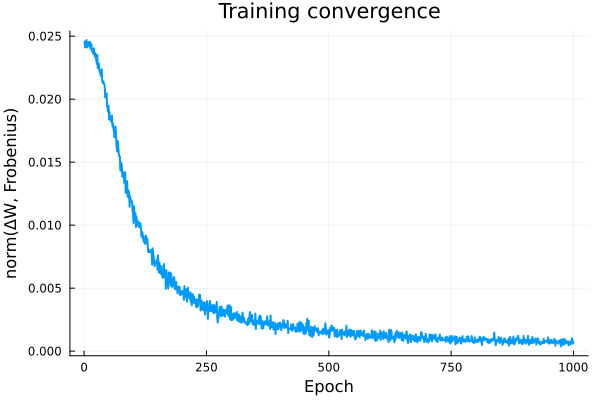

In [8]:
let

    theme(:light) # set the theme to dark for better aesthetics (on a dark background)
    plot(history;
        xlabel = "Epoch",
        ylabel = "norm(ΔW, Frobenius)",
        title = "Training convergence",
        legend = false,
        lw = 2,
    )

   # plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
end

__After training__: Now let's see how training changed the distribution. We reuse the same enumeration logic on `trained_model` with $\beta = 1.0$.

> __What do we expect after training?__
>
> After training, the weight updates should have shifted the Boltzmann distribution so that the two training patterns $[-1,-1,1]$ and $[1,1,-1]$ have higher probability relative to the untrained model.

We enumerate all configurations and compute the partition function for `trained_model`.

In [9]:
P_after = let

    β_train = 1.0;  # use same β as training
    N = 2^number_of_nodes;
    Z_vals = Dict{Int,Float64}();

    for i ∈ 0:(N - 1)
        sᵢ = digits(i, base = 2, pad = number_of_nodes) |> x -> 2 .* x .- 1 |> reverse;
        Z_vals[i] = exp(-β_train * energy(trained_model, sᵢ));
    end

    Z̄ = sum(values(Z_vals));
    P_after = Dict(i => Z_vals[i] / Z̄ for i ∈ 0:(N - 1));
    @assert sum(values(P_after)) ≈ 1.0;
    P_after
end

Dict{Int64, Float64} with 8 entries:
  0 => 0.000888926
  4 => 0.000913658
  5 => 0.000902381
  6 => 0.502771
  2 => 0.000906694
  7 => 0.00089256
  3 => 0.000901706
  1 => 0.491823

Let's compare the stationary distribution before and after training. The two training patterns are marked with an asterisk in the `trained` column.

> __What do we expect?__ After training, the two patterns $[-1,-1,1]$ and $[1,1,-1]$ should have higher probability in `P_after` than in `P_before`. The remaining six configurations should have correspondingly lower probability.

Do we see what we expect?

In [10]:
let
    N = 2^number_of_nodes;
    rows = NamedTuple[];
    training_patterns = [[-1, -1, 1], [1, 1, -1]];

    for i ∈ 0:(N - 1)
        sᵢ = digits(i, base = 2, pad = number_of_nodes) |> x -> 2 .* x .- 1 |> reverse;
        is_trained = any(sᵢ == p for p ∈ training_patterns) ? "*" : " ";
        push!(rows, (
            configuration = sᵢ,
            P_before = round(P_before[i]; digits = 4),
            P_after  = round(P_after[i];  digits = 4),
            trained  = is_trained,
        ));
    end

    pretty_table(rows;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
    );
end

 --------------- ---------- --------- ---------
  configuration   P_before   P_after   trained 
 --------------- ---------- --------- ---------
   [-1, -1, -1]     0.1253    0.0009
    [-1, -1, 1]     0.1232    0.4918         *
    [-1, 1, -1]     0.1255    0.0009
     [-1, 1, 1]      0.126    0.0009
    [1, -1, -1]      0.126    0.0009
     [1, -1, 1]     0.1255    0.0009
     [1, 1, -1]     0.1232    0.5028         *
      [1, 1, 1]     0.1253    0.0009
 --------------- ---------- --------- ---------


> __What does this result mean in practice?__ 
> 
> In this toy example, we trained on only two patterns, so the model moved most probability mass onto those two states. This is expected: Boltzmann training matches the model distribution to the data distribution.
>
> For larger systems, we do not enumerate all $2^N$ configurations. Instead, we estimate model statistics by sampling (for example Gibbs sampling / CD-style methods). But the same principle still holds: if the training data are narrow, the learned distribution will also be narrow. Better data coverage leads to broader, more representative models.

### Things to think about
* __Question__: From the `P_before` vs `P_after` table, how much probability mass shifts onto the two training patterns $[-1,-1,1]$ and $[1,1,-1]$ after training?

___

## Task 2: Let's explore a different memory matrix
One of the hard things to wrap our heads around is what we are actually learning when we train a Boltzmann machine. In Task 1, we trained on two complementary patterns, which should encourage the model to assign higher probability to those two configurations. 

But what if we trained on a different set of patterns? For example, what if we trained on the three patterns $[-1,-1,1]$, $[-1,1,-1]$, and $[1,-1,-1]$? Furthermore, what if some of these patterns were repeated more than others? How would that change the learned distribution? Let's check out this question.

Let's start by defining a different memory matrix, and then we'll run the same training procedure to see what the probability distribution looks like after training on this new set of patterns.

In [11]:
X₂ = let
    # define hand-picked 3-bit training patterns (columns of X)
    p1 = [-1, -1,  1];  # pattern 1
    p2 = [ -1,  1, -1];  # pattern 2
    p3 = [ 1, -1, -1];  # pattern 3

    # return -
    X = hcat(p1, p2, p3, p3); # X will be 3 x number_of_patterns
end

3×4 Matrix{Int64}:
 -1  -1   1   1
 -1   1  -1  -1
  1  -1  -1  -1

The matrix `X₂` stores training patterns as columns. Columns 3 and 4 are both `p3 = [1,-1,-1]`, so `p3` appears twice while `p1` and `p2` each appear once. Because training matches the model distribution to the empirical distribution of the columns, we expect the trained model to assign more probability to `p3`. 

We initialize a fresh model before training.

In [12]:
another_model_fresh = let
    
    # initialize - 
    n = number_of_nodes;
    
    # build random initial weights and biases
    W_init = 0.01 .* randn(n, n);
    W_init = W_init - diagm(diag(W_init));    # zero diagonal (no self-connections)
    W_init = (W_init + W_init') ./ 2;         # symmetrize
    b_init = zeros(n);

    # build the model -
    model = build(MySimpleBoltzmannMachineModel, (
        W = W_init, b = b_init
    ));

    # return -
    model;
end;

Now, we're ready to train. [The `learn(...)` function](src/Compute.jl) implements exact gradient ascent by running Gibbs sampling to stationarity at each epoch.

> __How does the `learn(...)` function update the model?__
>
> Each epoch runs Gibbs sampling until the chain reaches its stationary distribution, discards the first half of samples as burn-in, and computes pairwise correlations from the remaining samples. The weight update $\Delta\mathbf{W} = \eta\left(\mathbf{C}_{\text{data}} - \mathbf{C}_{\text{model}}\right)$ increases connection strength for pairs that co-activate in the data and decreases it for pairs that co-activate at model equilibrium.

`learn(...)` returns a tuple `(trained_model_2, history_2)`, where `trained_model_2::MySimpleBoltzmannMachineModel` holds the updated weights $\mathbf{W}$ and biases $\mathbf{b}$, and `history_2::Vector{Float64}` records the Frobenius norm $\|\Delta\mathbf{W}\|_{F}$ at each epoch. We run `N_epochs = 1000` epochs with `T = 10000` Gibbs steps per epoch.

In [13]:
trained_model_2, history_2 = learn(another_model_fresh, X₂; η = 0.01, β = 1.0, T = 10000, N_epochs = 1000);

Training is complete. We now compute the exact Boltzmann distribution for `trained_model_2` by enumerating all $2^3 = 8$ configurations and computing the partition function exactly.

In [14]:
P₂ = let

    # initialize -
    model = trained_model_2; # use the newly trained model
    β_train = 1.0;  # use same β as training
    N = 2^number_of_nodes;
    Z_vals = Dict{Int,Float64}();

    for i ∈ 0:(N - 1)
        sᵢ = digits(i, base = 2, pad = number_of_nodes) |> x -> 2 .* x .- 1 |> reverse;
        Z_vals[i] = exp(-β_train * energy(model, sᵢ));
    end

    Z̄ = sum(values(Z_vals));
    P₂ = Dict(i => Z_vals[i] / Z̄ for i ∈ 0:(N - 1));
    @assert sum(values(P₂)) ≈ 1.0;
    P₂
end

Dict{Int64, Float64} with 8 entries:
  0 => 1.20933e-19
  4 => 0.999962
  5 => 1.7425e-6
  6 => 1.69227e-6
  2 => 1.55103e-5
  7 => 5.19145e-27
  3 => 3.42329e-6
  1 => 1.51614e-5

Let's look at the stationary distribution after training. The three training patterns are marked with an asterisk in the `trained` column.

> __What do we expect?__ With `p3` appearing twice, we might expect $P([1,-1,-1]) \approx 0.5$ and $P([-1,-1,1]) \approx P([-1,1,-1]) \approx 0.25$. What we actually observe illustrates a key limitation of unconstrained gradient ascent, which we explore in the next section.

In [15]:
let
    N = 2^number_of_nodes;
    rows = NamedTuple[];
    training_patterns = Vector{Vector{Int}}(eachcol(X₂)); # extract the training patterns from the columns of X₂

    for i ∈ 0:(N - 1)
        sᵢ = digits(i, base = 2, pad = number_of_nodes) |> x -> 2 .* x .- 1 |> reverse;
        is_trained = any(sᵢ == p for p ∈ training_patterns) ? "*" : " ";
        push!(rows, (
            configuration = sᵢ,
            P_after  = round(P₂[i];  digits = 4),
            trained  = is_trained,
        ));
    end

    pretty_table(rows;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
    );
end

 --------------- --------- ---------
  configuration   P_after   trained 
 --------------- --------- ---------
   [-1, -1, -1]       0.0
    [-1, -1, 1]       0.0         *
    [-1, 1, -1]       0.0         *
     [-1, 1, 1]       0.0
    [1, -1, -1]       1.0         *
     [1, -1, 1]       0.0
     [1, 1, -1]       0.0
      [1, 1, 1]       0.0
 --------------- --------- ---------


__Hmmm. Why didn't that work?__ The one-hot result above comes from two causes working together. The [`learn(...)`](src/Compute.jl) function drives training by computing the **data correlation matrix** $\mathbf{C}^{\text{data}}$, where each entry

$$C_{ij}^{\text{data}} = \frac{1}{m}\sum_{r=1}^{m} s_i^{(r)} s_j^{(r)}$$

is the average product of the states of nodes $i$ and $j$ across the $m$ training patterns. The weight gradient pushes $w_{ij}$ to match the model correlation $C_{ij}^{\text{model}}$ to $C_{ij}^{\text{data}}$.

With equal counts of all three patterns, the data correlation matrix is symmetric: $C_{12} = C_{13} = C_{23} = -\frac{1}{3}$. The duplicate of `p3` breaks this symmetry. Computing entry by entry from the four columns of `X₂`:

| Pair $(i,j)$ | $C_{ij}^{\text{data}}$ |
|:---:|:---:|
| $(1,2)$ | $-\frac{1}{2}$ |
| $(1,3)$ | $-\frac{1}{2}$ |
| $(2,3)$ | $0$ |

Initially, $w_{23}$ receives no gradient signal (since $C_{23}^{\text{data}} = C_{23}^{\text{model}} \approx 0$ at initialization) while $w_{12}$ and $w_{13}$ are pushed strongly negative. Combined with negative bias gradients on nodes 2 and 3 (both are $-1$ in three of the four training patterns), this makes `[1,-1,-1]` increasingly favorable in energy. 

Since $P \propto e^{-\beta E}$, even a modest energy gap concentrates probability sharply, and unconstrained gradient ascent drives the weights toward $\pm\infty$, collapsing the distribution to a single configuration.

We compute $\mathbf{C}^{\text{data}}$ directly from the four columns of `X₂` to confirm the asymmetry described above.

In [16]:
C_data = let
    m = size(X₂, 2);       # number of training patterns (columns)
    (1/m) * (X₂ * X₂')     # 3×3 data correlation matrix
end

3×3 Matrix{Float64}:
  1.0  -0.5  -0.5
 -0.5   1.0   0.0
 -0.5   0.0   1.0

#### What should we expect from natural sampling?
To recover the true distribution from naturally sampled data, we need two things: draw many random samples so the duplicate counts reflect genuine probabilities, and use **L2 weight regularization** (weight decay, $\lambda > 0$) to add $-\lambda\mathbf{W}$ to each weight update and bound the weight magnitudes at equilibrium.

Let's try this again: we'll generate a larger number of samples from our three node system:

In [17]:
p1 = [-1, -1,  1]; # pattern 1
p2 = [-1,  1, -1]; # pattern 2
p3 = [ 1, -1, -1]; # pattern 3

We draw `m = 500` samples at random from the distribution $P(\mathbf{p}_1) = 0.25$, $P(\mathbf{p}_2) = 0.25$, $P(\mathbf{p}_3) = 0.50$. This gives a training matrix where `p3` appears roughly twice as often as `p1` and `p2`, reflecting natural sampling rather than a manually constructed duplicate.

We'll save the training matrix (with duplicates) in the `X_sampled::Array{Int,2}` variable. Each column of `X_sampled` is a training pattern.

In [18]:
X_sampled = let
    m = 500; # how many samples do we draw?
    patterns = [p1, p2, p3];
    probs = Weights([0.25, 0.25, 0.50]);
    idx = StatsBase.sample(1:3, probs, m);
    hcat(patterns[idx]...)
end

3×500 Matrix{Int64}:
 -1   1   1  -1  -1  -1   1  -1   1  …  -1  -1   1  -1  -1   1   1   1  -1
  1  -1  -1  -1   1   1  -1  -1  -1     -1   1  -1  -1   1  -1  -1  -1  -1
 -1  -1  -1   1  -1  -1  -1   1  -1      1  -1  -1   1  -1  -1  -1  -1   1

Next, let's create a fresh model and train it on `X_sampled` with L2 regularization.

In [19]:
model_sampled_fresh = let
    n = number_of_nodes;
    W_init = 0.01 .* randn(n, n);
    W_init = W_init - diagm(diag(W_init));
    W_init = (W_init + W_init') ./ 2;
    build(MySimpleBoltzmannMachineModel, (W = W_init, b = zeros(n)));
end;

We train using the same parameters as before, but with `λ = 0.05`. The weight decay term $-\lambda\mathbf{W}$ in each update limits weight growth and prevents the distribution from collapsing to a single configuration.

[`learn(...)`](src/Compute.jl) returns a tuple `(trained_model_sampled, history_sampled)`, where `trained_model_sampled::MySimpleBoltzmannMachineModel` holds the updated weights $\mathbf{W}$ and biases $\mathbf{b}$, and `history_sampled::Vector{Float64}` records the Frobenius norm $\|\Delta\mathbf{W}\|_{F}$ at each epoch.

In [20]:
trained_model_sampled, history_sampled = learn(model_sampled_fresh, X_sampled;
    η = 0.01, β = 1.0, T = 10000, N_epochs = 1000, λ = 0.05);

Training is complete. We enumerate all $2^3 = 8$ configurations and compute the exact Boltzmann distribution for `trained_model_sampled` with $\beta = 1.0$.

In [21]:
P_sampled = let
    model = trained_model_sampled;
    β_eval = 1.0;
    N = 2^number_of_nodes;
    Z_vals = Dict{Int,Float64}();
    for i ∈ 0:(N-1)
        sᵢ = digits(i, base=2, pad=number_of_nodes) |> x -> 2 .* x .- 1 |> reverse;
        Z_vals[i] = exp(-β_eval * energy(model, sᵢ));
    end
    Z̄ = sum(values(Z_vals));
    P = Dict(i => Z_vals[i] / Z̄ for i ∈ 0:(N-1));
    @assert sum(values(P)) ≈ 1.0;
    P
end;

We compare the trained distribution to the true target probabilities. With weight decay, `p3` should have roughly twice the probability of `p1` and `p2`, recovering the shape of the distribution used to generate the training data.

In [22]:
let
    N = 2^number_of_nodes;
    rows = NamedTuple[];
    true_probs = Dict(p1 => 0.25, p2 => 0.25, p3 => 0.50);

    for i ∈ 0:(N-1)
        sᵢ = digits(i, base=2, pad=number_of_nodes) |> x -> 2 .* x .- 1 |> reverse;
        is_target = haskey(true_probs, sᵢ) ? "*" : " ";
        push!(rows, (
            configuration = sᵢ,
            P_true    = get(true_probs, sᵢ, 0.0),
            P_trained = round(P_sampled[i]; digits = 4),
            target    = is_target,
        ));
    end

    pretty_table(rows;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
    );
end

 --------------- -------- ----------- --------
  configuration   P_true   P_trained   target 
 --------------- -------- ----------- --------
   [-1, -1, -1]      0.0      0.2521
    [-1, -1, 1]     0.25      0.1015        *
    [-1, 1, -1]     0.25      0.1195        *
     [-1, 1, 1]      0.0      0.0389
    [1, -1, -1]      0.5      0.2949        *
     [1, -1, 1]      0.0      0.0813
     [1, 1, -1]      0.0      0.0915
      [1, 1, 1]      0.0      0.0204
 --------------- -------- ----------- --------


## Summary
This lab trained a Boltzmann machine using exact gradient ascent and demonstrated how training data composition directly determines the learned distribution.

> __Key Takeaways__
>
> * **Training shifts probability mass:** After training on two complementary patterns, the Boltzmann machine assigns most probability to those patterns, confirming that gradient ascent matches the model distribution to the empirical data distribution.
> * **Duplicate patterns cause collapse:** A manually duplicated pattern breaks symmetry in the data correlation matrix, giving one edge pair zero gradient initially while others grow without bound, collapsing the learned distribution to a single configuration.
> * **Weight regularization prevents collapse:** Adding L2 weight decay bounds weight magnitudes at equilibrium, and drawing training samples from the true distribution provides unbiased gradient estimates, together recovering an approximate target distribution.

The one-shot collapse observed here motivates the development of restricted Boltzmann machines and contrastive divergence, which reduce the cost and instability of the negative phase.
___